__Markus Mulvihill__

__Last updated April 2026__

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib
import plt_config

 

Within this file, different methods of parameter estimation will be implemented and compared to predict the Insulin Sensitivity $\, SI$ in patients

In [2]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_integral_static_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_integral_static_04.npy")
    SI_errs_int_static = SI_errs.copy()
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_integral_static_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Parameter_estimation_integral.py")

Run 04_Parameter_estimation_integral.py


In [3]:
total_mard = np.average(SI_errs, axis=(0, 1))
print("Total MARD: ", total_mard)

Total MARD:  0.06142751737467808


In [4]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_integral_vary_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_integral_vary_04.npy")
    SI_errs_int_vary = SI_errs.copy()
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_integral_vary_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Parameter_estimation_integral_vary.py")

Loaded variables


In [5]:
total_mard = np.average(SI_errs, axis=(0, 1))
print("Total MARD: ", total_mard)

Total MARD:  0.0625729895667034


In [3]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_augment_static_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_augment_static_04.npy")
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_augment_static_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment.py")

Loaded variables


In [4]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "04"
num_particles = cfg[curr_module]["num_particles"]
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]
dev_perc = cfg[curr_module]["dev_perc"]
deviations = cfg[curr_module]["deviations"]
num_deviations = len(deviations)

filters = ["EKF"]
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)

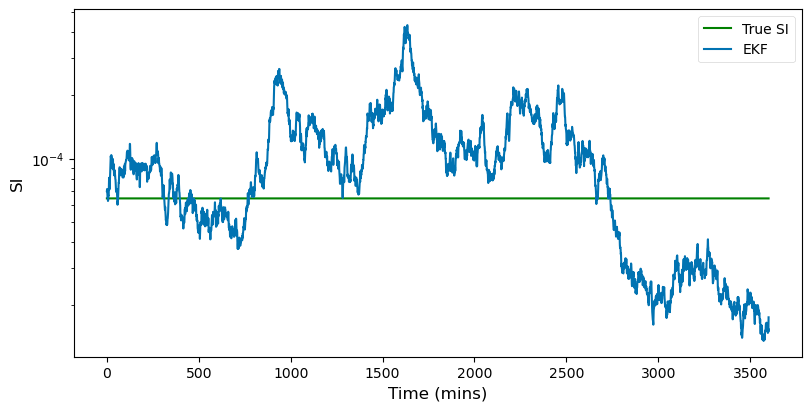

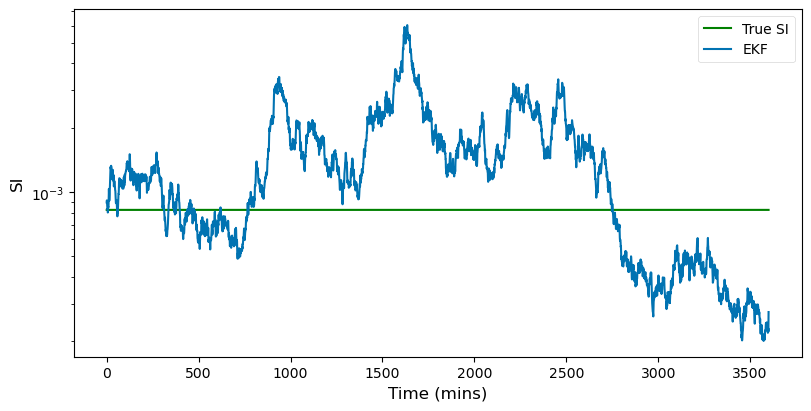

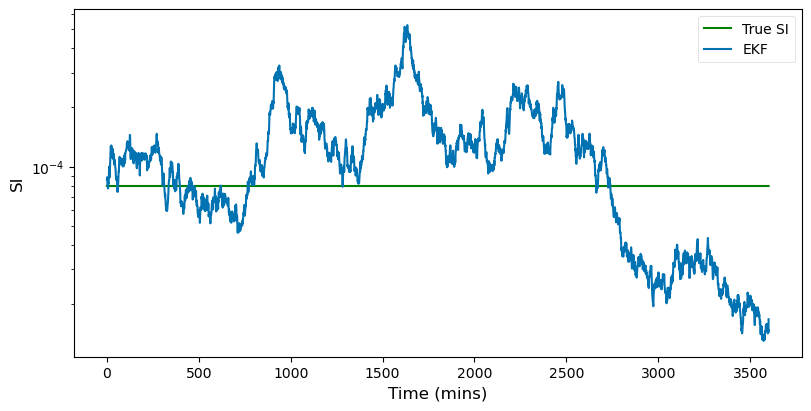

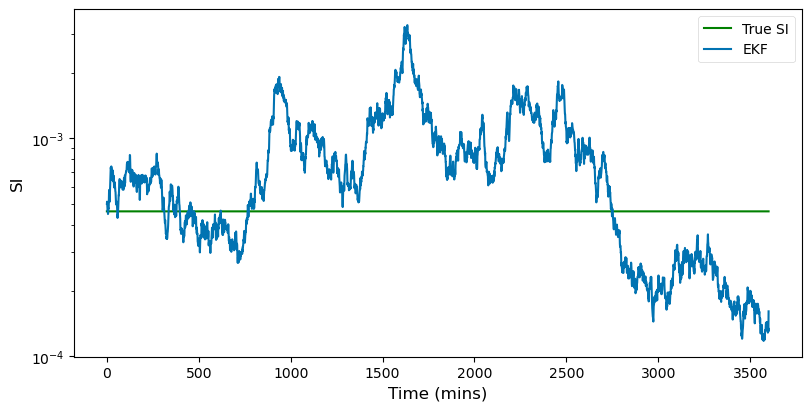

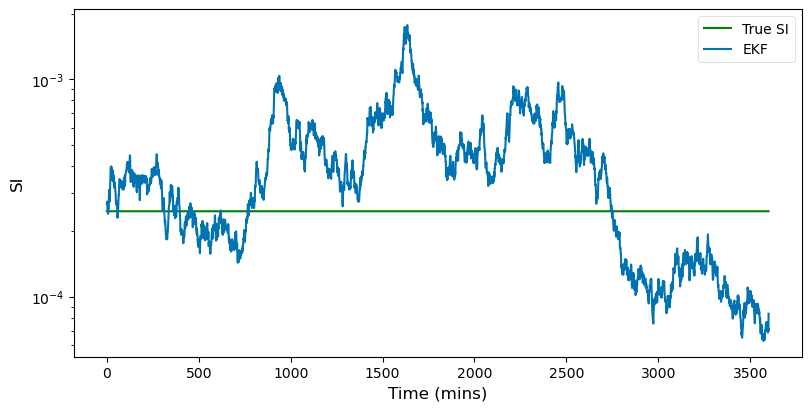

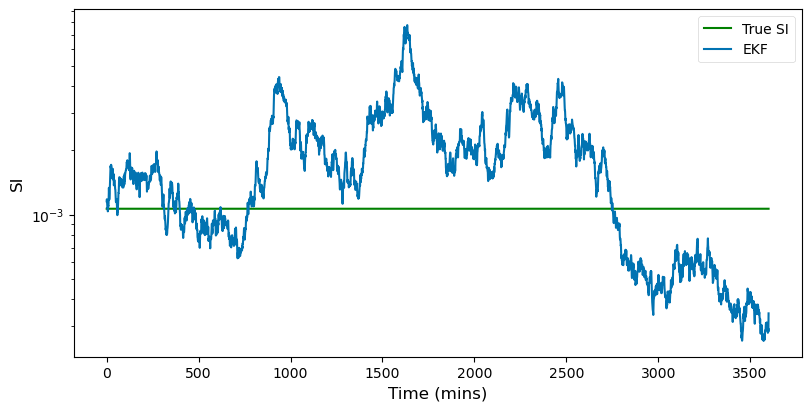

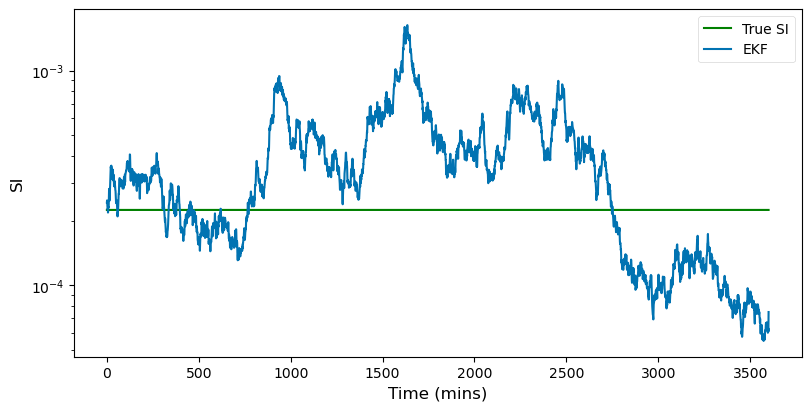

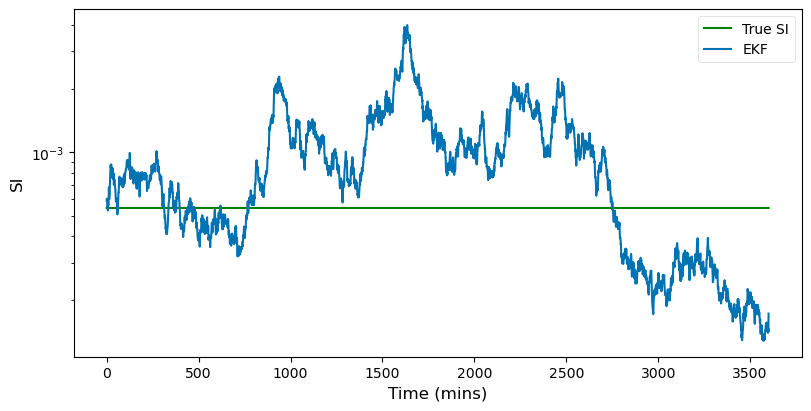

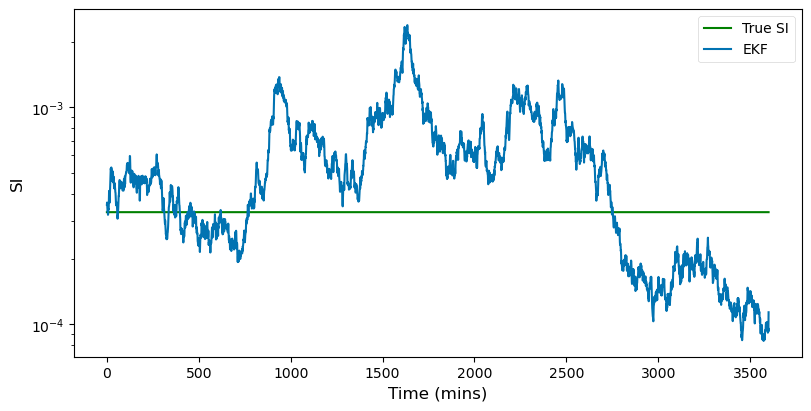

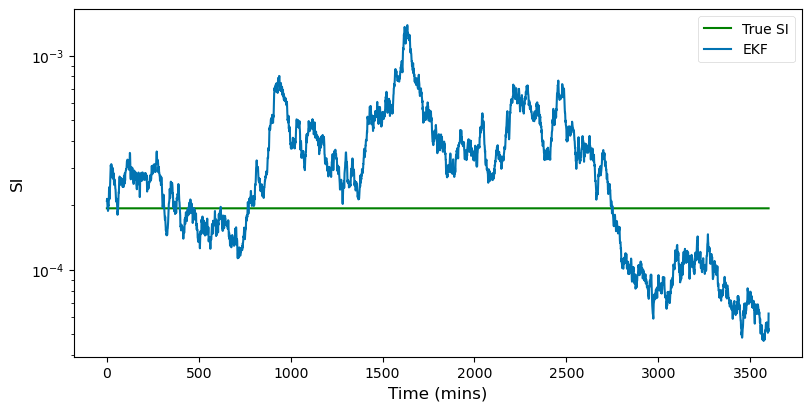

In [5]:
time = np.arange(SI_true_arr.shape[1])
num_filters = len(filters) - 1
palette = sns.color_palette("colorblind", num_filters + 1)
deviation = 0

for i in range(10):
    fig, ax = plt.subplots(figsize=(8, 4))
    true_SI = SI_true_arr[i, :]
    ax.semilogy(time, true_SI, color="green", label="True SI")
    for j in range(num_filters):
        patient = i
        est = SI_ests[deviation, j, i, :]
        ax.semilogy(time, est, linestyle="-", color=palette[j], label=f"{filters[j]}")

    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("SI")
    ax.legend()

In [12]:
total_mard = np.average(SI_errs, axis=(2, 3))
print("Total MARD: ", total_mard)

Total MARD:  [[56.29564459  0.        ]]


In [11]:
try:
    SI_ests = np.load("../scripts/variables/SI_ests_augment_vary_04.npy")
    SI_errs = np.load("../scripts/variables/SI_errs_augment_vary_04.npy")
    SI_true_arr = np.load("../scripts/variables/SI_true_arr_augment_vary_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment_vary.py")

Loaded variables


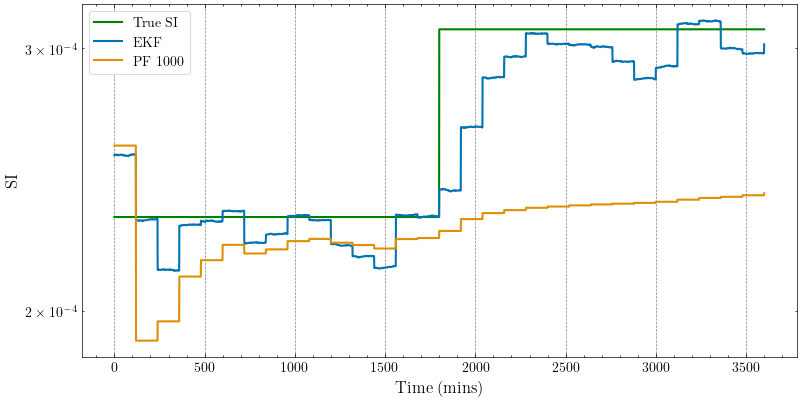

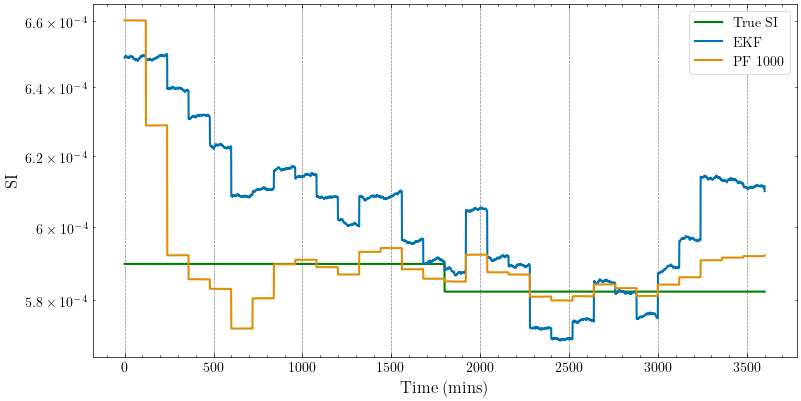

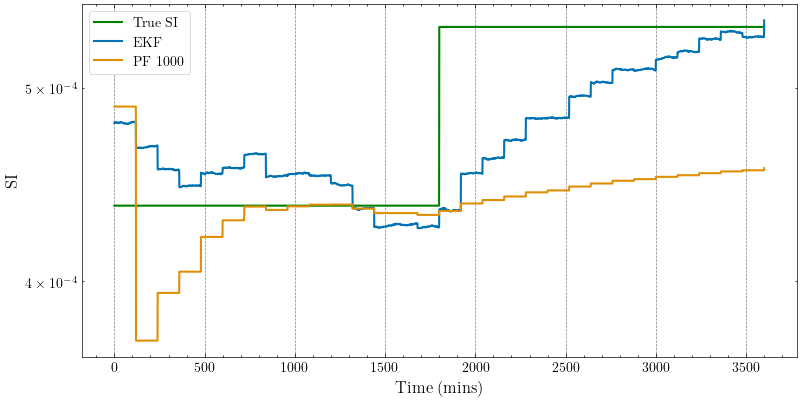

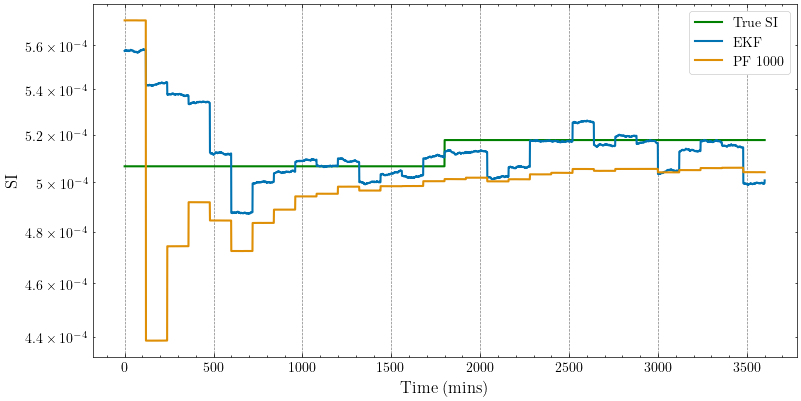

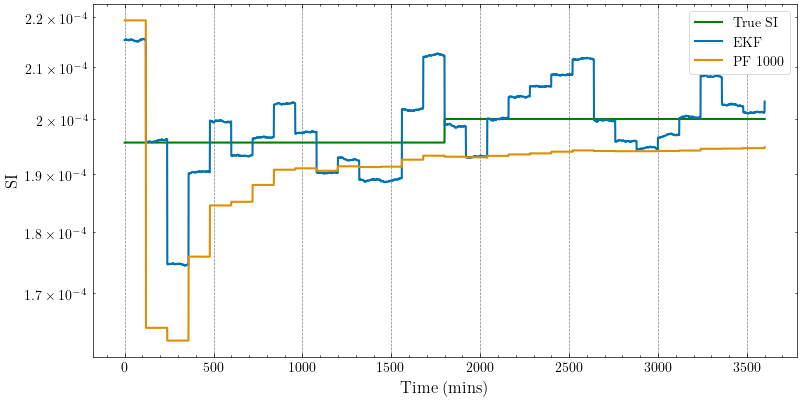

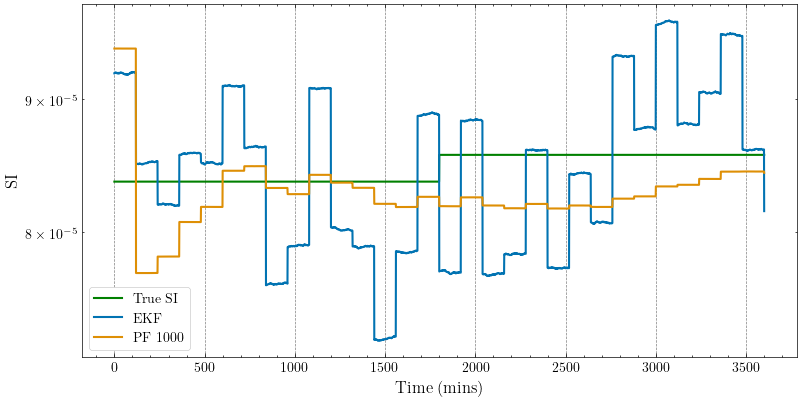

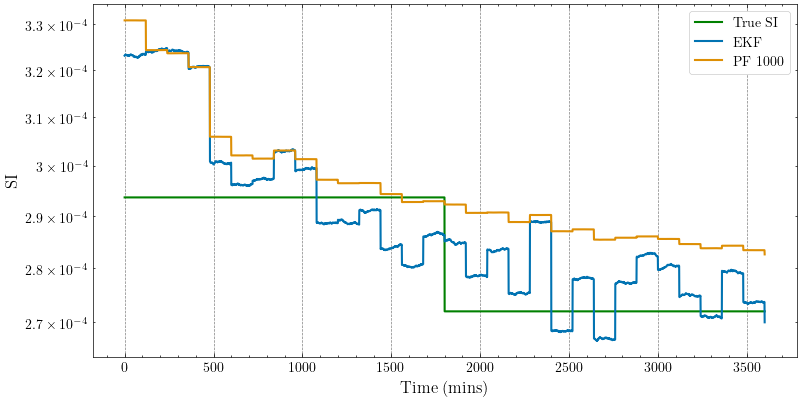

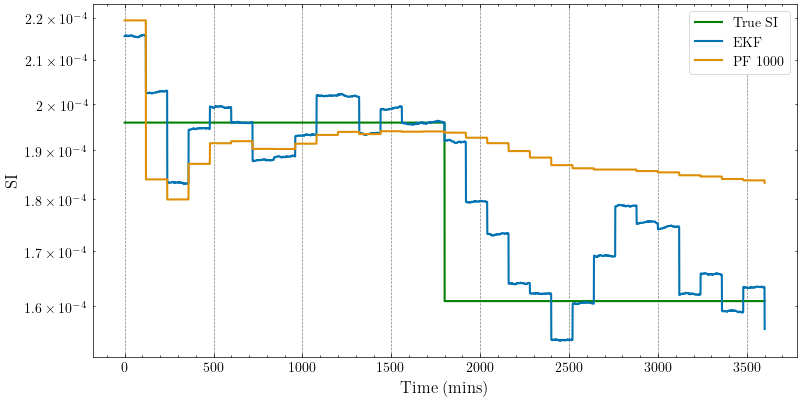

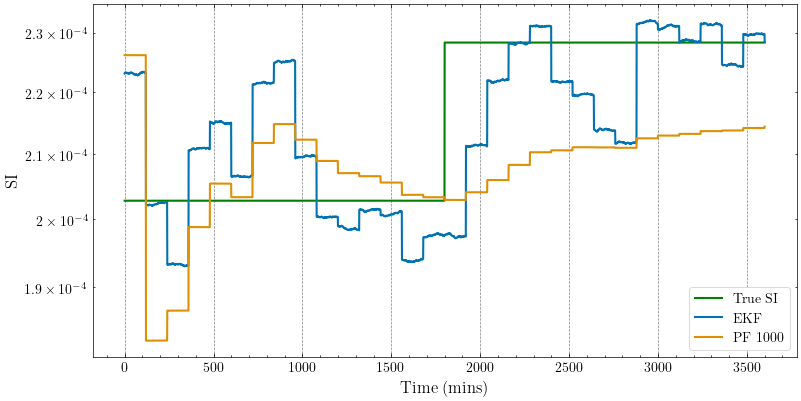

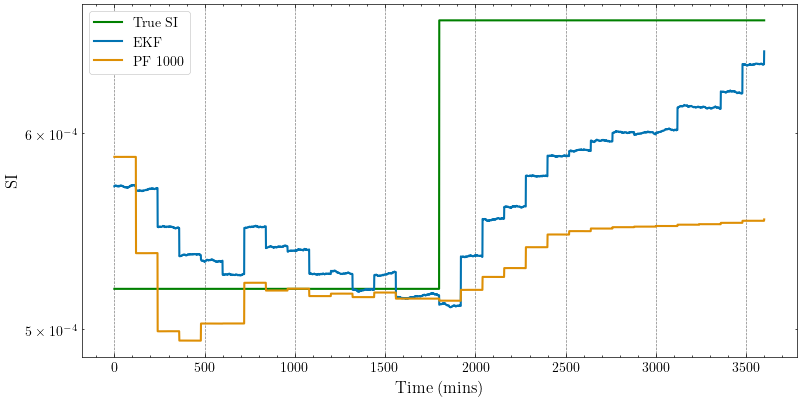

In [12]:
time = np.arange(SI_true_arr.shape[1])
num_filters = len(filters)
palette = sns.color_palette("colorblind", num_filters+1)
deviation = 0

for i in range(10):
    fig, ax = plt.subplots(figsize=(8, 4))
    true_SI = SI_true_arr[i, :]
    ax.semilogy(time, true_SI, color="green", label="True SI")
    for j in range(num_filters):
        patient = i
        est = SI_ests[deviation, j, i, :]
        ax.semilogy(time, est, linestyle="-", color=palette[j], label=f"{filters[j]}")

    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("SI")
    ax.legend()

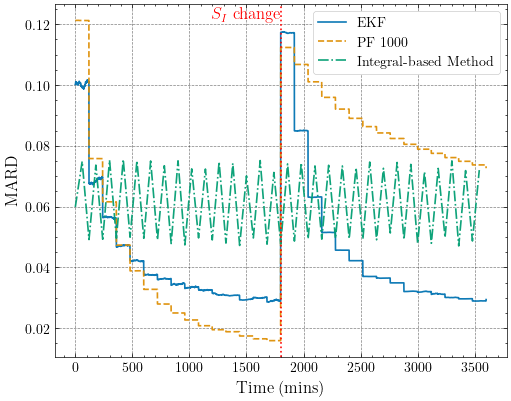

In [17]:
for j in range(num_deviations):
    mean_err = np.mean(SI_errs[j, :, :, :], axis=1)
    time = np.arange(mean_err.shape[1])
    mean_err_int = np.mean(SI_errs_int_static, axis=0)
    time_int = 60*np.arange(mean_err_int.shape[0])
    num_plots = len(filters)
    num_filters = len(filters)
    palette = sns.color_palette("colorblind", num_filters+1)

    fig, ax = plt.subplots(figsize=(5.1, 4))

    for i in range(num_plots):
        ax.plot(
            time,
            mean_err[i] / 100,
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"{filters[i]}",
        )
   import ax.plot(
        time_int,
        mean_err_int, 
        color=palette[2],
        linewidth=1.2,
        alpha=0.95,
        linestyle="-.",
        label="Integral-based Method",
    ) 

    x = 1800
    plt.axvline(x=x, color='red', linewidth=1.2, alpha=0.95, linestyle=":")
    ymin, ymax = plt.ylim()
    ypos = ymin + 0.95*(ymax - ymin)   # adjust vertical offset as needed
    plt.text(x + 5, ypos, r"$\,S_I$ change", color='red', va='bottom', ha='right')
    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("MARD")
    ax.legend(loc="best") 
    fig.savefig("figures/5_5.pdf", format="pdf")


In [14]:
total_mard = np.average(SI_errs / 100, axis=(2, 3))
print("Total MARD: ", total_mard)
print(np.average(mean_err_int))

Total MARD:  [[0.0445238  0.06246614]]
0.061427517374678074
